# Visualizing the sequence → peak landscape

Figures for the peak-conditioned design work in this folder. Each section is one figure with its
caption underneath, in the order they would appear in a write-up.

1. **Landscape ruggedness** — the curated 758 laid out in sequence space, with excitation and
   emission raised into the third dimension so the map becomes a terrain. Static first, then the
   same two terrains as rotatable Plotly scenes.
2. **The same ruggedness, in one dimension** — the same phenomenon along a single t-SNE axis.
3. **The map in true colour** — the flat counterpart, with every protein painted the visible
   colour of its own peak instead of a chosen gradient.
4. **The dual train/val/test split** — how the surrogate and oracle splits are carved from each other.
5. **Architecture sweep, surrogate** — a 48-way sweep on ESM-2, ranked against an NN floor.
6. **Architecture sweep, oracle** — the same sweep, run independently on ProstT5.

Figures follow the **2026 Arcadia style guide**, matching
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb):
Atkinson Hyperlegible Next for text, Atkinson Hyperlegible Mono for numerals, the Arcadia magma
gradient wherever a wavelength is shaded continuously, and charts titled in the caption rather
than in the figure.

> Run from `esm2_design/`. Both prerequisites live in `dataset_pipeline/` and are one-off:
> `python fetch_arcadia_fonts.py` (fonts, seconds) and
> `python embed_fpbase_maxpool.py` (embedding cache, a couple of minutes on GPU/MPS).

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import hashlib
import json
import os

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import arcadia_pycolor as apc

# Everything this notebook reads is produced under dataset_pipeline/, including the Atkinson
# faces; without them matplotlib silently falls back to its defaults.
DP = "../dataset_pipeline"
FONTS = f"{DP}/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

PROT_JSON = f"{DP}/../fpbase-extractor/fpbase_output/fpbase_proteins.json"
EMB_NPY = f"{DP}/data/fpbase_esm2_650M_max.npy"
EMB_META = f"{DP}/data/fpbase_esm2_650M_max.meta.json"
CURATED = f"{DP}/data/peak/curated"
FIGDIR = "../figures"                # shared repo-level figures/, matching dataset_pipeline's convention

assert os.path.exists(EMB_NPY), "run `python embed_fpbase_maxpool.py` in dataset_pipeline/ first"
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The same helpers the curation notebook uses. Panel geometry is expressed in the guide's pixels
(Full_wide 1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib
point is exactly one style-guide pixel.

One departure: excitation and emission are shaded on a **single shared** magma normalization
spanning both, rather than each panel getting its own scale. A given colour therefore means the
same wavelength in both panels, and the two terrains can be read against each other.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

# Continuous scale for wavelength. Magma is Arcadia's default gradient; its cool-to-warm run keeps
# short and long wavelengths reading the intuitive way round. The very top of the ramp is dropped
# because it approaches the page white and would make the reddest proteins disappear.
PEAK_CMAP = LinearSegmentedColormap.from_list(
    "apc:magma_dots", apc.gradients.magma.to_mpl_cmap()(np.linspace(0.04, 0.86, 256))
)


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def panel_letter_3d(ax, letter, x=0.02, y=0.84):
    """Panel letter on a 3-D axes.

    Axes3D has no annotate in axes coordinates, so use text2D. A 3-D axes also insets its drawn
    cube well within its own bbox, so the letter sits lower than the 2-D convention would put it,
    which keeps it beside the plot rather than adrift in the margin.
    """
    ax.text2D(x, y, letter, transform=ax.transAxes, ha="left", va="bottom", **PANEL_LETTER)

## 1. Landscape ruggedness

### 1.1 Rebuild the curation notebook's sequence-space map

The layout is taken from Figure 1 of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) and is reproduced here
**exactly**: the same max-pooled ESM-2 embedding of all 990 sequenced FPbase proteins, standardized,
compressed to 50 principal components, then t-SNE with `init="pca"`, perplexity 30 and
`random_state=0`.

The fit deliberately stays on all 990. Dropping the excluded proteins *before* the fit would move
every surviving point, because t-SNE's layout depends on the whole neighbour graph; keeping them in
and discarding their coordinates afterwards means each of the 758 sits precisely where the curation
figure put it. So this is a subset of that map, not a new one.

Membership is matched **on the sequence** rather than the slug, since stage C of the pipeline
collapses each group of identical sequences to one representative row and slug matching would miss
the duplicates that were folded away.

In [3]:
proteins = json.load(open(PROT_JSON))
meta = json.load(open(EMB_META))

prot = pd.DataFrame([
    {
        "slug": p.get("slug", ""),
        "name": p.get("name", ""),
        "organism": p.get("parent_organism") or "",
        "seq": (p.get("seq") or "").strip().upper(),
    }
    for p in proteins
    if (p.get("seq") or "").strip()
])

# embed_fpbase_maxpool.py records an md5 over the exact sequence list it embedded; rebuilding the
# same list here and checking it guarantees each embedding row still lines up with a row of prot.
md5 = hashlib.md5("\x00".join(prot.seq).encode()).hexdigest()
assert md5 == meta["seq_md5"], "embedding cache is stale -- rerun embed_fpbase_maxpool.py"

Z = np.load(EMB_NPY)
assert len(Z) == len(prot)

curated = pd.read_csv(f"{CURATED}/peaks_assignments.csv").sort_values("index").reset_index(drop=True)
prot["is_true_fp"] = prot.seq.isin(set(curated.seq))

print(f"{len(proteins)} FPbase entries | {len(prot)} with a sequence | "
      f"embedding {Z.shape} ({meta['model']}, layer {meta['layer']}, {meta['pooling']}-pooled)")
print(f"curated peak set: {len(curated)} rows, {prot.is_true_fp.sum()} of the {len(prot)} "
      f"sequenced proteins map into it")

1041 FPbase entries | 990 with a sequence | embedding (990, 1280) (esm2_t33_650M_UR50D, layer 33, max-pooled)
curated peak set: 758 rows, 758 of the 990 sequenced proteins map into it


In [4]:
Zstd = StandardScaler().fit_transform(Z)
pca50 = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca50.fit_transform(Zstd)
print(f"50-PC embedding: {Z50.shape} ({pca50.explained_variance_ratio_.sum():.1%} variance retained)")

xy = TSNE(n_components=2, metric="euclidean", init="pca", perplexity=30,
          learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x"], prot["y"] = xy[:, 0], xy[:, 1]

# Keep only the curated rows, in peaks.npy order, so x/y/ex/em stay index-aligned with the
# rest of the pipeline (dual_splits.csv, the embedding caches, peaks_assignments.csv).
seq_to_row = {s: i for i, s in enumerate(prot.seq)}
rows = curated.seq.map(seq_to_row)
assert rows.notna().all(), "every curated sequence should be in the embedding table"
rows = rows.astype(int).to_numpy()
assert len(set(rows)) == len(rows) == len(curated), "curated rows must map one-to-one"

x, y = prot.x.to_numpy()[rows], prot.y.to_numpy()[rows]
ex = curated.ex_max.to_numpy(float)
em = curated.em_max.to_numpy(float)
names = curated.name.to_numpy()

print(f"t-SNE fitted on all {len(prot)}, kept the {len(x)} curated")
print(f"excitation {ex.min():.0f}-{ex.max():.0f} nm | emission {em.min():.0f}-{em.max():.0f} nm")

50-PC embedding: (990, 50) (84.3% variance retained)


t-SNE fitted on all 990, kept the 758 curated
excitation 343-611 nm | emission 414-684 nm


### 1.2 Turn the point cloud into a terrain

With the map as the ground plane, each protein's peak becomes a height, and the 758 points become
a surface over Delaunay triangles of the t-SNE coordinates.

Delaunay triangulates the *convex hull*, so it happily spans the empty gaps between clusters and
would draw sheer walls where there is simply no data. Every triangle whose longest edge exceeds the
90th percentile is therefore masked out. The threshold is a heuristic and it is the one dial in the
figure: raising it bridges more gaps with invented surface, lowering it fragments real
neighbourhoods. It is reported below so the choice stays visible.

Relief is not smoothed. Interpolating or averaging the heights would flatten exactly the feature
this figure exists to show, so neighbouring sequences with very different peaks stay as the near
vertical faces they are.

In [5]:
EDGE_PCTL = 90                    # drop triangles whose longest edge is above this percentile

tri_all = mtri.Triangulation(x, y)
t = tri_all.triangles
# longest side of each triangle, from the three (vertex, next vertex) pairs
edge_len = np.sqrt((x[t] - x[np.roll(t, 1, axis=1)]) ** 2
                   + (y[t] - y[np.roll(t, 1, axis=1)]) ** 2).max(axis=1)
edge_cut = np.percentile(edge_len, EDGE_PCTL)

surf = mtri.Triangulation(x, y)
surf.set_mask(edge_len > edge_cut)

# One scale for both panels so a colour and a height mean the same thing in each.
PEAK_NORM = Normalize(vmin=min(ex.min(), em.min()), vmax=max(ex.max(), em.max()))
ZLIM = (PEAK_NORM.vmin - 10, PEAK_NORM.vmax + 10)


def robust_lims(v, pad=0.04):
    """Axis limits covering the bulk, so a few stray points cannot shrink the terrain."""
    lo, hi = np.percentile(v, [1, 99])
    margin = (hi - lo) * pad
    return lo - margin, hi + margin


XLIM, YLIM = robust_lims(x), robust_lims(y)

print(f"{len(t)} Delaunay triangles | longest edge <= {edge_cut:.1f} keeps "
      f"{(~surf.mask).sum()} ({(~surf.mask).mean():.0%})")
print(f"shared height scale: {PEAK_NORM.vmin:.0f}-{PEAK_NORM.vmax:.0f} nm")

1504 Delaunay triangles | longest edge <= 8.9 keeps 1353 (90%)
shared height scale: 343-684 nm


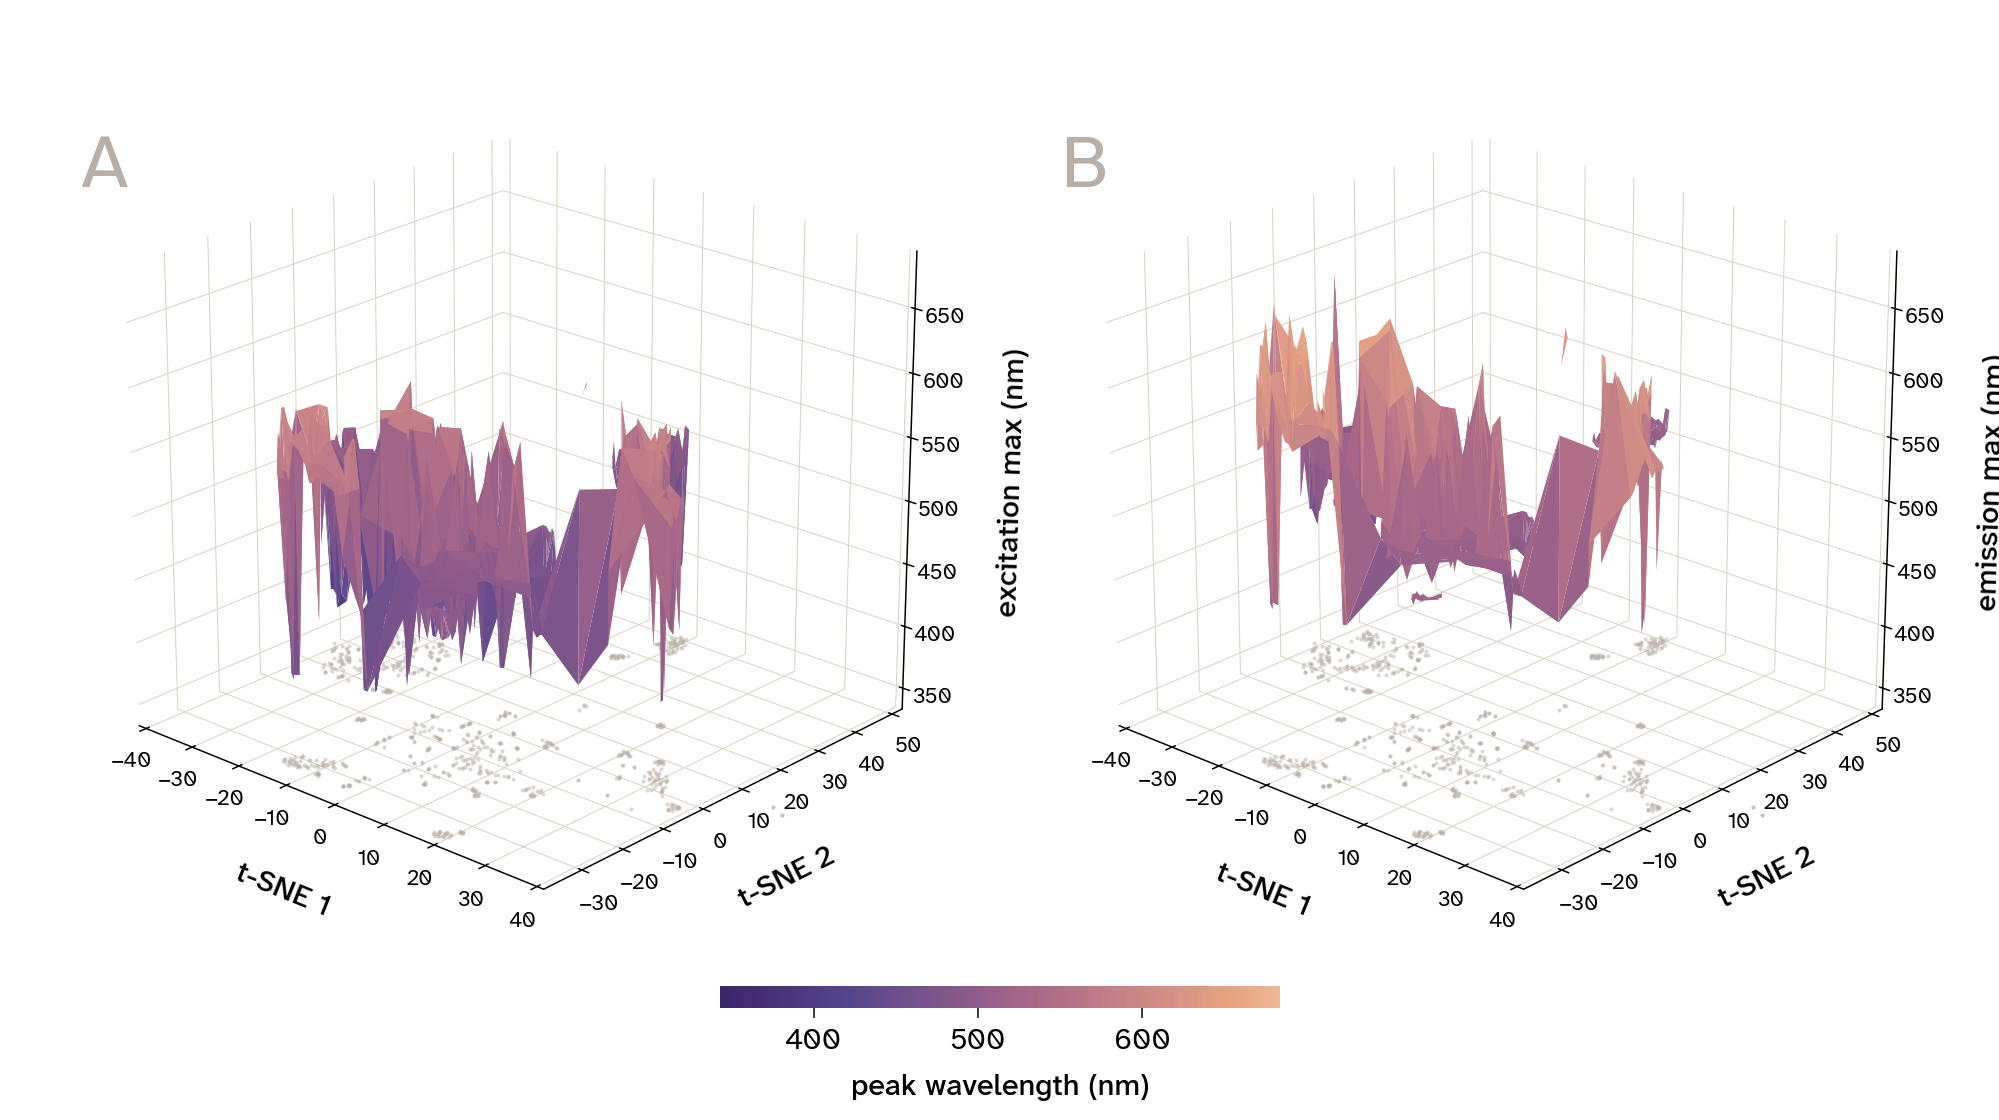

2103 edges in the drawn mesh
  |dex| median  18 nm   p90 102 nm
  |dem| median  10 nm   p90  74 nm
  0.5(|dex|+|dem|): median 16.5 nm | 39% under 10 nm | 23% over 50 nm | max 218 nm

steepest faces in the terrain:
    218 nm   mNeptune684            (604, 684)   vs   mTagBFP2               (399, 454)
    216 nm   mNeptune684            (604, 684)   vs   secBFP2                (399, 456)
    212 nm   mCarmine               (603, 675)   vs   mTagBFP2               (399, 454)
    206 nm   Electra1               (402, 454)   vs   mGarnet2               (598, 671)
    206 nm   Electra2               (403, 454)   vs   mGarnet2               (598, 671)


In [6]:
ELEV, AZIM = 22, -48              # low enough that the cliff faces are seen edge-on
FIG_H = 560

fig = plt.figure(figsize=(FULL_WIDE * PX, FIG_H * PX))
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.15, top=0.95, wspace=0.0)

for i, (z, what, letter) in enumerate([(ex, "excitation", "A"), (em, "emission", "B")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # the t-SNE map itself, dropped onto the floor so the terrain keeps its footprint
    ax.scatter(x, y, zs=ZLIM[0], zdir="z", s=4, c=NEUTRAL, alpha=0.5, depthshade=False)
    ax.plot_trisurf(surf, z, cmap=PEAK_CMAP, norm=PEAK_NORM,
                    linewidth=0, edgecolor="none", antialiased=True)

    ax.set(xlim=XLIM, ylim=YLIM, zlim=ZLIM,
           xlabel="t-SNE 1", ylabel="t-SNE 2", zlabel=f"{what} max (nm)")
    ax.set_box_aspect((1, 1, 0.9))
    ax.view_init(elev=ELEV, azim=AZIM)
    # the guide's 0.75pt rules; Axes3D panes are drawn instead of spines
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor(NEUTRAL_SOFT)
        axis.pane.set_alpha(1.0)
        axis._axinfo["grid"].update(color=NEUTRAL_SOFT, linewidth=0.5)
    ax.tick_params(labelsize=11, pad=1)
    panel_letter_3d(ax, letter)

# One shared colourbar: the height scale is common to both panels, so one key serves them both.
cax = fig.add_axes([0.36, 0.10, 0.28, 0.020])
bar = fig.colorbar(plt.cm.ScalarMappable(norm=PEAK_NORM, cmap=PEAK_CMAP),
                   cax=cax, orientation="horizontal")
bar.set_label("peak wavelength (nm)")
bar.outline.set_visible(False)
apc.mpl.set_colorbar_ticklabel_monospaced(cax)

fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.svg")
fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.png", dpi=200)
plt.show()

# Relief along the drawn mesh: how far the peaks move between two proteins the surface joins.
# This is the terrain's steepness expressed as a number, over the same edges the eye is reading.
kept = surf.triangles[~surf.mask]
sides = np.concatenate([kept[:, [0, 1]], kept[:, [1, 2]], kept[:, [2, 0]]])
pairs = np.unique(np.sort(sides, axis=1), axis=0)      # each shared side counted once
i, j = pairs[:, 0], pairs[:, 1]
d_ex, d_em = np.abs(ex[i] - ex[j]), np.abs(em[i] - em[j])
d_peak = 0.5 * (d_ex + d_em)

print(f"{len(pairs)} edges in the drawn mesh")
print(f"  |dex| median {np.median(d_ex):3.0f} nm   p90 {np.percentile(d_ex, 90):3.0f} nm")
print(f"  |dem| median {np.median(d_em):3.0f} nm   p90 {np.percentile(d_em, 90):3.0f} nm")
print(f"  0.5(|dex|+|dem|): median {np.median(d_peak):.1f} nm | "
      f"{100 * np.mean(d_peak < 10):.0f}% under 10 nm | {100 * np.mean(d_peak > 50):.0f}% over 50 nm | "
      f"max {d_peak.max():.0f} nm")
print("\nsteepest faces in the terrain:")
for k in np.argsort(-d_peak)[:5]:
    print(f"  {d_peak[k]:5.0f} nm   {names[i[k]][:22]:22} ({ex[i[k]]:.0f}, {em[i[k]]:.0f})"
          f"   vs   {names[j[k]][:22]:22} ({ex[j[k]]:.0f}, {em[j[k]]:.0f})")

**Figure 1. The sequence → peak map is a rugged terrain, not a smooth surface.** The 758 curated
proteins placed at their coordinates in the Figure-1 t-SNE of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) (max-pooled ESM-2,
standardize → PCA-50 → t-SNE, perplexity 30, fitted on all 990 sequenced FPbase proteins), with
**(A)** excitation and **(B)** emission maximum as height. The surface is the Delaunay
triangulation of the map, with the longest tenth of triangles removed so no sheet is drawn across
empty space; grey dots on the floor mark every protein, including those the mask leaves uncovered.
Both panels share one height scale and one colour scale, so A and B can be read against each other.

The terrain is the argument. If sequence neighbourhood determined colour, this would be a set of
gently sloping plateaus; instead broad flats are cut by near-vertical faces, and the drop is often
the full height of the axis. Along the edges the surface actually draws, the two peaks move by a
median of only 16.5 nm — but 23% of those edges span more than 50 nm and the steepest reach 218 nm.
The mesh is roughly two-fifths flat and half cliff.

The steepest faces are not exotic pairings. `mNeptune684` (604, 684 nm) sits beside `mTagBFP2`
(399, 454 nm), a 218 nm drop; `mGarnet2` sits beside `Electra1`. In fact all five of the steepest
faces printed above are between proteins whose `parent_organism` is *Entacmaea quadricolor* — every
one an engineered descendant of the same eqFP578 ancestor, adjacent in embedding space, at opposite
ends of the visible spectrum. The cliffs are not gaps between distant families; they are inside a
single lineage.

This is the geometry behind the honest-split result in [`cluster_split/`](cluster_split). A model
that interpolates smoothly across sequence space must fall off these faces, which is why
extrapolation error to unseen lineages (~27–30 nm) runs roughly double the random-split figure.

Panel A is visibly rougher than panel B, and the numbers agree: excitation moves by a median 18 nm
between mesh neighbours against emission's 10 nm, with a 90th percentile of 102 nm against 74 nm.
Excitation is the harder of the two peaks to predict from sequence neighbourhood alone.

Two caveats. t-SNE distances are **not** quantitative — cluster sizes and the gaps between them
carry no meaning, and the axes have no fixed orientation, so read horizontal position as "what
groups with what" and nothing more. And the surface is an artefact of the triangulation, not a
measurement: only the vertices are data.

### 1.3 The same two terrains, interactive

A fixed camera is a poor way to read relief: whichever angle is chosen, some cliffs are face-on and
others hide behind the ridge in front of them. The cells below rebuild both panels as rotatable
Plotly scenes from exactly the same triangulation, height scale and colour scale, so nothing about
the data changes — only the ability to move the camera.

Drag to rotate, scroll to zoom, and **hover any vertex to identify the protein**, which is the part
the static figure cannot do: the spikes stop being anonymous and become named FPs with their peaks
and ancestral organism attached. Hovering along the edge of any cliff is the quickest way to see
the *Entacmaea* pattern noted in the caption above for yourself.

Each scene is also written to a standalone HTML file in `figures/`, openable in a browser without
Jupyter. Section 1.2's static SVG remains the version to put in a write-up.

In [7]:
import plotly.graph_objects as go

# Plotly wants an explicit list of colour stops, so sample the same magma ramp the static
# figure uses. 32 stops is past the point where banding is visible.
PEAK_COLORSCALE = [
    [s, f"rgb({int(255 * r)},{int(255 * g)},{int(255 * b)})"]
    for s, (r, g, b, _) in zip(np.linspace(0, 1, 32), PEAK_CMAP(np.linspace(0, 1, 32)))
]

organisms = curated.parent_organism.fillna("unrecorded").to_numpy()
kept_tri = surf.triangles[~surf.mask]              # the same faces the static figure draws


def ruggedness_scene(z, what, height=640):
    """One rotatable terrain: masked Delaunay mesh + hoverable vertices + the map on the floor."""
    hover = np.stack([names, organisms, ex, em], axis=1)
    fig = go.Figure()

    # The mesh carries the surface; hovering it would report triangle interiors rather than
    # proteins, so identification is left to the vertex layer below.
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        i=kept_tri[:, 0], j=kept_tri[:, 1], k=kept_tri[:, 2],
        intensity=z, colorscale=PEAK_COLORSCALE,
        cmin=PEAK_NORM.vmin, cmax=PEAK_NORM.vmax,
        flatshading=True, hoverinfo="skip", showscale=True,
        colorbar=dict(title=dict(text="peak (nm)", side="right"), thickness=14, len=0.55),
        lighting=dict(ambient=0.62, diffuse=0.85, specular=0.12, roughness=0.9),
        lightposition=dict(x=100, y=-200, z=400),
    ))

    # Vertices are the only real data points, so they carry the hover.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="markers",
        marker=dict(size=2, color="rgba(20,20,20,0.55)"),
        customdata=hover,
        hovertemplate=("<b>%{customdata[0]}</b><br>%{customdata[1]}"
                       "<br>ex %{customdata[2]:.0f} nm · em %{customdata[3]:.0f} nm"
                       "<extra></extra>"),
        showlegend=False,
    ))

    # Footprint of the map, including the proteins the edge mask leaves uncovered.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=np.full_like(z, ZLIM[0]), mode="markers",
        marker=dict(size=1.6, color=NEUTRAL, opacity=0.5),
        hoverinfo="skip", showlegend=False,
    ))

    fig.update_layout(
        template="plotly_white", width=900, height=height,
        margin=dict(l=0, r=0, t=28, b=0),
        title=dict(text=f"{what} max over the sequence-space map", x=0.02, font=dict(size=15)),
        scene=dict(
            xaxis=dict(title="t-SNE 1", range=list(XLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            yaxis=dict(title="t-SNE 2", range=list(YLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            zaxis=dict(title=f"{what} max (nm)", range=list(ZLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            aspectratio=dict(x=1, y=1, z=0.9),          # matches the static set_box_aspect
            camera=dict(eye=dict(x=1.36, y=-1.52, z=0.83)),   # ~ elev 22, azim -48
        ),
    )
    return fig


scenes = {"excitation": ruggedness_scene(ex, "Excitation"),
          "emission": ruggedness_scene(em, "Emission")}
for what, fig in scenes.items():
    path = f"{FIGDIR}/landscape_ruggedness_{what}.html"
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    print(f"wrote {path}")

wrote ../figures/landscape_ruggedness_excitation.html
wrote ../figures/landscape_ruggedness_emission.html


In [8]:
scenes["excitation"].show()

In [9]:
scenes["emission"].show()

## 2. The same ruggedness, in one dimension

Figure 1's terrain needs two embedding axes and a height to show its cliffs. The same phenomenon
survives a much blunter projection: a single t-SNE dimension, fit with the same protocol (PCA-50
then t-SNE, perplexity 30, `random_state=0`) on all 990 sequenced proteins and then restricted to
the 758 curated, exactly as `x`/`y` were in Section 1.1. Sorting the curated set by that one
coordinate and drawing excitation and emission as two lines turns the surface's cliffs into
spikes: proteins that land next to each other on this single axis can still be tens of nanometres
apart in peak.

In [10]:
xy1 = TSNE(n_components=1, metric="euclidean", init="pca", perplexity=30,
           learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x1d"] = xy1[:, 0]
x1d = prot.x1d.to_numpy()[rows]                    # same curated subset/order as x, y, ex, em

order = np.argsort(x1d)
x1d_s, ex_s, em_s = x1d[order], ex[order], em[order]
X1DLIM = robust_lims(x1d)

# Ruggedness restated in 1D: how far the peak jumps between proteins that are now adjacent
# only because they landed next to each other on a single sorted axis.
d_ex1, d_em1 = np.abs(np.diff(ex_s)), np.abs(np.diff(em_s))
print(f"1D t-SNE fitted on all {len(prot)}, kept the {len(x1d)} curated")
print(f"adjacent-in-1D jump: |dex| median {np.median(d_ex1):.1f} nm, max {d_ex1.max():.0f} nm | "
      f"|dem| median {np.median(d_em1):.1f} nm, max {d_em1.max():.0f} nm")

1D t-SNE fitted on all 990, kept the 758 curated
adjacent-in-1D jump: |dex| median 14.0 nm, max 217 nm | |dem| median 7.0 nm, max 230 nm


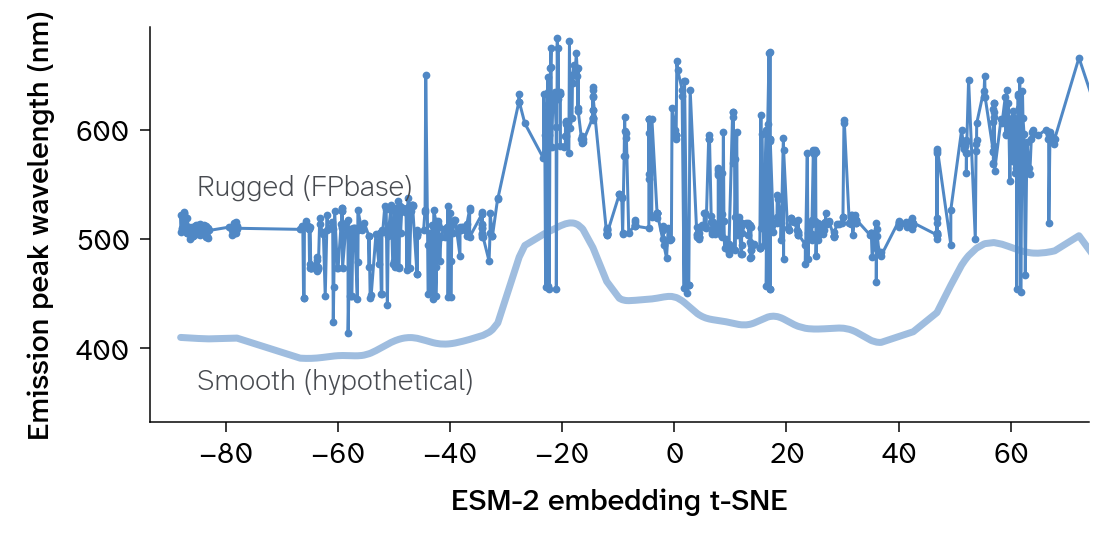

In [11]:
BANDWIDTH = 3.0          # t-SNE units, Gaussian kernel width for the smoothed reference below
EM_SMOOTH_OFFSET = 100   # nm, purely a display offset so the trend band clears the raw line

# Nadaraya-Watson kernel regression: a Gaussian-kernel-weighted local average of emission at each
# point, weighting every other point by its distance along the 1D axis rather than a fixed-count
# window -- the same kernel-density idea used to smooth a distribution, applied here to smooth a
# curve instead of a histogram.
d = (x1d_s[:, None] - x1d_s[None, :]) / BANDWIDTH
w = np.exp(-0.5 * d ** 2)
em_smooth = (w @ em_s) / w.sum(axis=1)

FIG_W, FIG_H = FULL_WIDE * 5 / 9, FULL_WIDE * 5 / 18

fig, ax = plt.subplots(figsize=(FIG_W * PX, FIG_H * PX))
fig.subplots_adjust(left=0.135, right=0.98, bottom=0.24, top=0.95)

# Smoothed reference shifted down by a fixed offset -- purely for display, so the thick trend band
# clears the noisy raw line instead of sitting inside it. The offset carries no information; it's
# called out in the in-line label and caption so it's never mistaken for a value.
ax.plot(x1d_s, em_smooth - EM_SMOOTH_OFFSET, color=HIGHLIGHT, lw=3.5, alpha=0.55,
        solid_capstyle="round", zorder=1)
ax.plot(x1d_s, em_s, color=HIGHLIGHT, lw=1.5, zorder=2)
ax.scatter(x1d_s, em_s, color=HIGHLIGHT, s=15, zorder=2)

# Each curve labelled in place instead of a legend -- text stays Charcoal per the guide (data
# colours never carry text), positioned by proximity to the curve it names.
ax.annotate("Rugged (FPbase)", xy=(x1d_s[0], em_s[0]+10), xycoords="data",
            xytext=(8, 10), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate("Smooth (hypothetical)", xy=(x1d_s[0], em_smooth[0] - EM_SMOOTH_OFFSET - 10),
            xycoords="data", xytext=(8, -10), textcoords="offset points", ha="left", va="top",
            **ANNOTATION)

ax.set(xlim=X1DLIM, ylim=ZLIM, xlabel="ESM-2 embedding t-SNE", ylabel="Emission peak wavelength (nm)")
apc.mpl.style_plot(ax, monospaced_axes="both")

fig.savefig(f"{FIGDIR}/landscape_ruggedness_1d.svg")
fig.savefig(f"{FIGDIR}/landscape_ruggedness_1d.png", dpi=200)
plt.show()

**Figure 2. Even a single embedding axis can't smooth over the cliffs: proteins that land next to
each other in this 1D projection can still be 200+ nm apart in emission.** Emission peak plotted
against a 1D t-SNE re-embedding of the same max-pooled ESM-2 representation used throughout
(PCA-50 -> t-SNE, one component, perplexity 30, fitted on all 990 sequenced proteins and restricted
to the 758 curated), sorted along that single axis. The thick, pale band is a Gaussian-kernel
(Nadaraya-Watson) smoothing of the same points -- a weighted local average, the same idea a KDE
uses to smooth a distribution, applied here to smooth a curve -- standing in for what a *smooth*
landscape would predict. It is shifted down 100 nm purely so it clears the raw line instead of
sitting inside it; the offset carries no information of its own.

Between proteins that are now adjacent only because a single number placed them next to each
other, the median jump is a modest 7.0 nm, but the tails are not: the steepest single step reaches
230 nm. The smoothed reference is genuinely smooth -- a few gentle undulations across the whole
axis -- while the real signal spikes far above and below it throughout, including in the regions
where the trend is flattest. Collapsing the map from two dimensions (and a height) to one makes the
story simpler to read but no less true: sequence similarity, even along the algorithm's single
best-guess ordering, still fails to predict peak wavelength for a meaningful fraction of
neighbours.

## 3. The same map in true colour

Figure 1 uses height for the peak and a magma ramp for the colour, which is legible but arbitrary:
nothing about magma says "580 nm". Here the third dimension is dropped and the peak is encoded the
one way that needs no key at all — **each protein is painted the colour of its own peak
wavelength**, so a 480 nm excitation dot is cyan because 480 nm light is cyan.

The mapping is Dan Bruton's visible-spectrum approximation, the piecewise-linear ramp conventionally
used to render the visible spectrum. It is chosen over a colorimetric CIE conversion on purpose:
converting monochromatic light to sRGB puts the spectral locus far outside the display gamut, and
the usual desaturation fixes turn deep violet and deep red into muddy blue and pink. Bruton's ramp
is not colorimetrically exact, but it produces the violet → blue → green → yellow → red sequence a
reader expects, which is what a colour key needs to do.

Two adjustments, both visible in the code. Brightness is floored so that the deepest violets and
reds stay legible instead of fading to black at the ends of the ramp, and wavelengths are clamped
to 380–700 nm. Clamping touches only the **6 excitation peaks below 380 nm** — genuinely
ultraviolet, so they have no colour to be shown in — and nothing at the red end, where the reddest
protein reaches 684 nm.

In [12]:
from matplotlib.colors import ListedColormap

VIS_LO, VIS_HI = 380.0, 700.0     # the range the approximation is defined over


def wavelength_rgb(lam, floor=0.55, gamma=0.8):
    """Wavelength in nm -> sRGB, by Dan Bruton's visible-spectrum approximation.

    `floor` lifts the brightness falloff at both ends of the ramp so that violet and deep-red
    markers stay visible on the page rather than fading to black; `gamma` is Bruton's 0.8
    display correction. Input is clamped to the visible range, so anything ultraviolet is drawn
    as 380 nm violet and anything infrared as 700 nm red.
    """
    w = np.clip(np.asarray(lam, dtype=float), VIS_LO, VIS_HI)
    r, g, b = (np.zeros_like(w) for _ in range(3))

    m = (w >= 380) & (w < 440); r[m] = -(w[m] - 440) / 60; b[m] = 1
    m = (w >= 440) & (w < 490); g[m] = (w[m] - 440) / 50; b[m] = 1
    m = (w >= 490) & (w < 510); g[m] = 1; b[m] = -(w[m] - 510) / 20
    m = (w >= 510) & (w < 580); r[m] = (w[m] - 510) / 70; g[m] = 1
    m = (w >= 580) & (w < 645); r[m] = 1; g[m] = -(w[m] - 645) / 65
    m = w >= 645; r[m] = 1

    fade = np.ones_like(w)                                   # Bruton's end-of-range dimming
    m = w < 420; fade[m] = 0.3 + 0.7 * (w[m] - 380) / 40
    m = w > 645; fade[m] = 0.3 + 0.7 * (700 - w[m]) / 55
    fade = floor + (1 - floor) * np.clip(fade, 0, 1)

    return np.clip((np.stack([r, g, b], axis=-1) * fade[..., None]) ** gamma, 0, 1)


# Colourbar ramp over the same shared span the Figure 1 panels use, so the two figures agree.
SPECTRAL_CMAP = ListedColormap(
    wavelength_rgb(np.linspace(PEAK_NORM.vmin, PEAK_NORM.vmax, 512)), name="visible_spectrum")

n_uv = int((ex < VIS_LO).sum() + (em < VIS_LO).sum())
n_ir = int((ex > VIS_HI).sum() + (em > VIS_HI).sum())
print(f"{n_uv} peaks below {VIS_LO:.0f} nm and {n_ir} above {VIS_HI:.0f} nm are clamped "
      f"(of {2 * len(ex)} values)")
print(f"bluest excitation  {names[ex.argmin()]} at {ex.min():.0f} nm")
print(f"reddest emission   {names[em.argmax()]} at {em.max():.0f} nm")

6 peaks below 380 nm and 0 above 700 nm are clamped (of 1516 values)
bluest excitation  Sumire at 343 nm
reddest emission   mNeptune684 at 684 nm


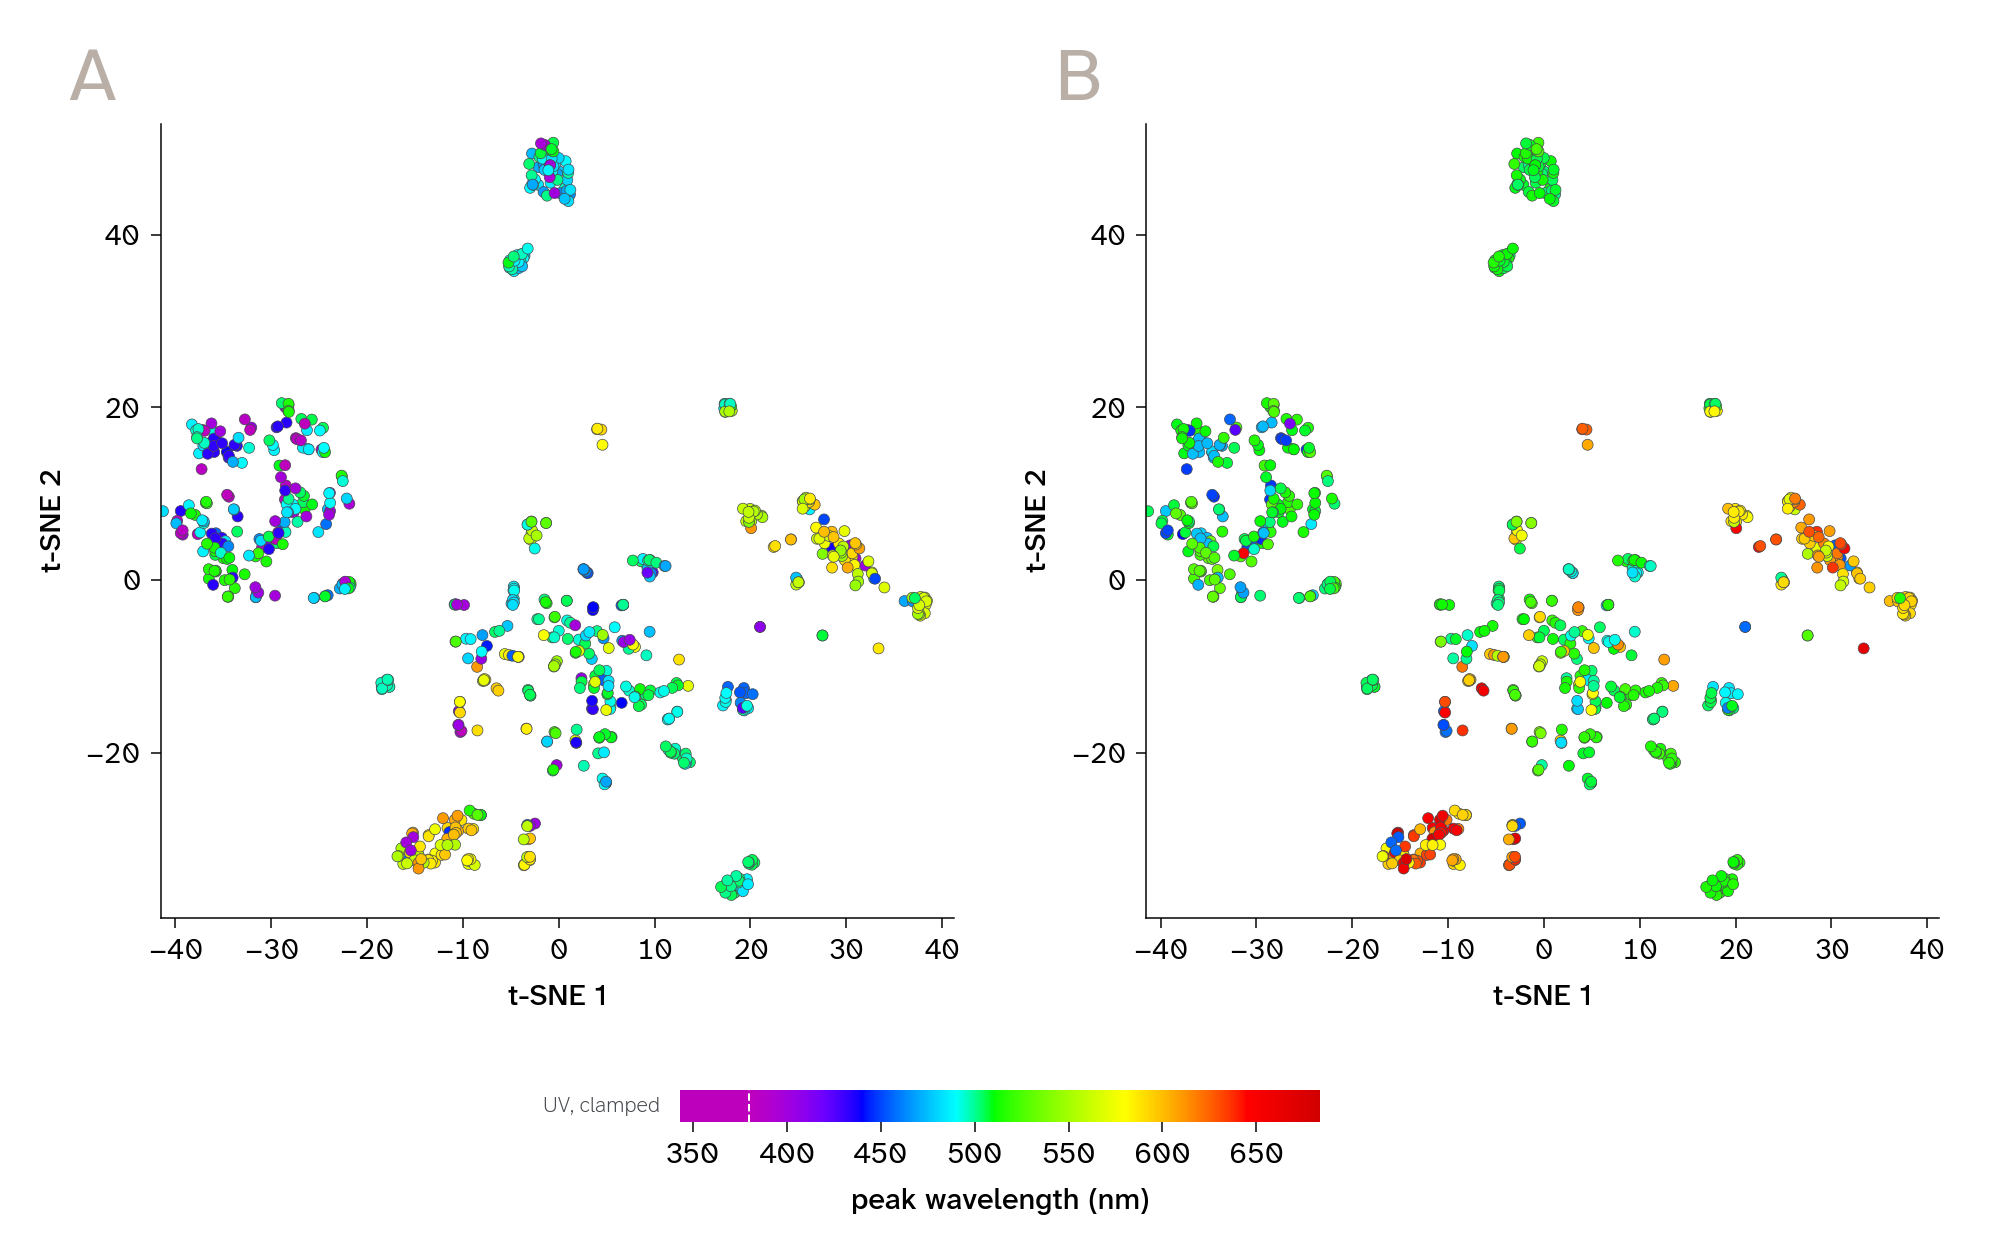

In [13]:
FIG2_H = 620

fig = plt.figure(figsize=(FULL_WIDE * PX, FIG2_H * PX))
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.26, top=0.90, wspace=0.18)

for i, (z, letter) in enumerate([(ex, "A"), (em, "B")]):
    ax = fig.add_subplot(1, 2, i + 1)
    # a thin charcoal edge keeps the yellow-green markers from bleaching into the page
    ax.scatter(x, y, s=30, c=wavelength_rgb(z), linewidths=0.35, edgecolors=str(apc.charcoal))
    ax.set(xlim=XLIM, ylim=YLIM, xlabel="t-SNE 1", ylabel="t-SNE 2")
    ax.set_box_aspect(1)
    apc.mpl.style_plot(ax, monospaced_axes="both")
    panel_letter(ax, letter, dy=6)

cax = fig.add_axes([0.34, 0.095, 0.32, 0.026])
bar = fig.colorbar(plt.cm.ScalarMappable(norm=PEAK_NORM, cmap=SPECTRAL_CMAP),
                   cax=cax, orientation="horizontal")
bar.set_label("peak wavelength (nm)")
bar.outline.set_visible(False)
apc.mpl.set_colorbar_ticklabel_monospaced(cax)
# mark where the ramp stops being physical, since the six UV excitations all pile up on this edge.
# The note sits to the left of the bar rather than above it, clear of the panels' axis labels.
cax.axvline(VIS_LO, color="white", lw=1, ls="--")
cax.annotate("UV, clamped", xy=(0, 0.5), xycoords="axes fraction",
             xytext=(-10, 0), textcoords="offset points", ha="right", va="center",
             **{**ANNOTATION, "fontsize": 11})

fig.savefig(f"{FIGDIR}/landscape_truecolour_tsne.svg")
fig.savefig(f"{FIGDIR}/landscape_truecolour_tsne.png", dpi=200)
plt.show()

**Figure 3. The curated set in sequence space, painted the colour of its own light.** The same
t-SNE coordinates as Figure 1, with each of the 758 proteins drawn in the visible colour of its
**(A)** excitation and **(B)** emission maximum (Bruton approximation, brightness floored, clamped
to 380–700 nm; the six ultraviolet excitations pile up at the violet end of the key and are marked
there). Both panels share the 343–684 nm key, so a colour means the same wavelength in either.

What Figure 1 renders as relief, this renders as colour mixing, and the two say the same thing.
A smooth sequence → peak map would give tidy monochrome patches. Instead most groups are stippled:
neighbouring dots run violet to yellow inside a single cluster, which is the same cliff structure
seen edge-on in Figure 1.

The dataset contains both extremes, and the split is by lineage. *Cytaeis uchidae* (the StayGold
group, n = 16) spans **6 nm** of emission and *Lobophyllia hemprichii* (n = 29) spans **10 nm** —
these are the near-uniform green blocks. *Entacmaea quadricolor* (n = 83) spans **230 nm**, and
*Discosoma* (n = 77) **195 nm**: single ancestral lineages that engineering has pushed across
essentially the whole visible range. A model cannot treat sequence proximity as colour proximity
when the same neighbourhood contains both regimes.

Reading A against B also shows the asymmetry noted under Figure 1 from a different angle. Panel A
carries most of the violet and deep blue, and its clusters look more broken up than the same
clusters in B — *Aequorea victoria* spreads 176 nm in excitation but only 124 nm in emission. B is
uniformly shifted red, which is just the Stokes shift: every protein emits to the red of where it
absorbs, so no dot moves left between the panels.

The Figure 1 caveats carry over: t-SNE distances are not quantitative, so only *what groups with
what* is meaningful, not how far apart groups sit.

## 4. The dual train/val/test split

Figures 5 and 6 each rank a 48-architecture sweep by validation MAE, but the two sweeps don't share
a split. The surrogate (ESM-2, guides generation) and the oracle (ProstT5, independently evaluates
it) are each scored on their own train/val/test partition of the same 758 curated proteins, built
by [`../dataset_pipeline/make_dual_split.py`](../dataset_pipeline/make_dual_split.py)
(`SEED = 0`, 70/15/15 after pinning 14 proteins to fixed roles).

The two splits are not independent draws. The oracle's is carved directly out of the surrogate's
training pool, using a second seed (`SEED + 1`): every protein the surrogate holds out (its own val
or test) lands in the oracle's *training* set, and the oracle's own held-out proteins are drawn from
*inside* the surrogate's training set. The two validation sets never overlap. The net effect: for
every one of the 758 proteins, at least one of the two models actually trained on it -- nothing is
invisible to both.

In [14]:
dual = pd.read_csv(f"{CURATED}/dual_splits.csv").sort_values("index").reset_index(drop=True)
# dual_splits.csv and peaks_assignments.csv are both built off the same curated index, so a
# straight row check is enough to confirm dual lines up with curated (and so with x, y, ex, em).
assert len(dual) == len(curated), "dual_splits.csv should cover exactly the curated set"
assert (dual.name.to_numpy() == curated.name.to_numpy()).all(), "row order must match curated/x/y"

ROLE_ORDER = ["train", "val", "test"]
ctab = pd.crosstab(dual.surrogate_role, dual.oracle_role).reindex(
    index=ROLE_ORDER, columns=ROLE_ORDER, fill_value=0)
print(ctab)
print()
print("surrogate:", dual.surrogate_role.value_counts().reindex(ROLE_ORDER).to_dict())
print("oracle:   ", dual.oracle_role.value_counts().reindex(ROLE_ORDER).to_dict())

either_train = ((dual.surrogate_role == "train") | (dual.oracle_role == "train")).mean()
print(f"\nat least one model trained on {either_train:.0%} of the 758 proteins")

oracle_role     train  val  test
surrogate_role                  
train             304  112   112
val               112    0     0
test              118    0     0

surrogate: {'train': 528, 'val': 112, 'test': 118}
oracle:    {'train': 534, 'val': 112, 'test': 112}

at least one model trained on 100% of the 758 proteins


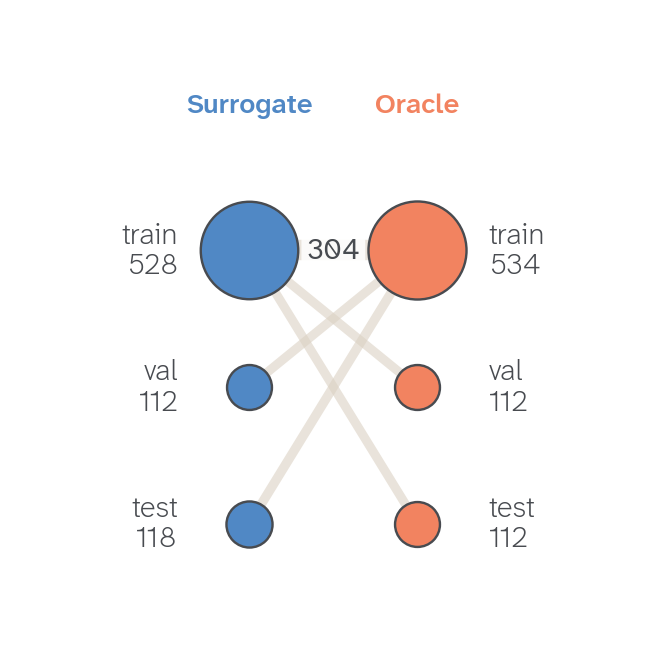

In [15]:
NODE_EDGE = str(apc.charcoal)
LX, RX = 0.0, 2.0
yp = {"train": 2, "val": 1, "test": 0}
cmax = ctab.to_numpy().max()
Stot = ctab.sum(axis=1)          # per surrogate role, across all oracle roles
Otot = ctab.sum(axis=0)          # per oracle role, across all surrogate roles

fig, ax = plt.subplots(figsize=(FULL_WIDE / 3 * PX, FULL_WIDE / 3 * PX))
fig.subplots_adjust(left=0.16, right=0.84, bottom=0.06, top=0.88)
NODE_SCALE = 4.5        # points^2 per protein -- tuned so the largest (train) bubble clears its label

# Line weight scales with how many proteins share that surrogate/oracle role pair; the pairs with
# no line are the split's enforced invariants, not missing data. Only the train-train link is
# labelled with its count -- every other pair's midpoint is shared with a second, differently
# valued link (e.g. both S_train-O_val and S_val-O_train read 112), so a number there would either
# duplicate or overlap rather than read cleanly; train-train has no such collision.
for s in ROLE_ORDER:
    for o in ROLE_ORDER:
        c = ctab.loc[s, o]
        if c == 0:
            continue
        ax.plot([LX, RX], [yp[s], yp[o]], lw=1.2 + 9 * c / cmax, color=NEUTRAL_SOFT,
                alpha=0.6, zorder=1, solid_capstyle="round")
        if s == "train" and o == "train":
            ax.text(LX + 0.5 * (RX - LX), yp[s] + 0.5 * (yp[o] - yp[s]), f"{c}",
                    ha="center", va="center", zorder=3,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
                    **NUMBER_NOTE)

# Node size scales with the role's total (across the other side), Aegean for surrogate roles and
# Amber for oracle roles -- the same highlight/contrast pairing Figures 5-6 use for the two models.
for s in ROLE_ORDER:
    ax.scatter([LX], [yp[s]], s=NODE_SCALE * Stot[s], color=HIGHLIGHT, ec=NODE_EDGE, lw=1.2, zorder=2)
    ax.text(LX - 0.85, yp[s], f"{s}\n{Stot[s]}", ha="right", va="center", **ANNOTATION)
for o in ROLE_ORDER:
    ax.scatter([RX], [yp[o]], s=NODE_SCALE * Otot[o], color=CONTRAST, ec=NODE_EDGE, lw=1.2, zorder=2)
    ax.text(RX + 0.85, yp[o], f"{o}\n{Otot[o]}", ha="left", va="center", **ANNOTATION)

ax.set_xlim(-1.7, 3.7)
ax.set_ylim(-0.75, 3.25)
frac_LX = (LX - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0])
frac_RX = (RX - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0])
ax.text(frac_LX, 0.94, "Surrogate", transform=ax.transAxes, ha="center",
        fontsize=14, fontweight="semibold", color=HIGHLIGHT)
ax.text(frac_RX, 0.94, "Oracle", transform=ax.transAxes, ha="center",
        fontsize=14, fontweight="semibold", color=CONTRAST)
ax.axis("off")

fig.savefig(f"{FIGDIR}/dual_split_overview.svg")
fig.savefig(f"{FIGDIR}/dual_split_overview.png", dpi=200)
plt.show()

**Figure 4. The surrogate and oracle splits are carved from each other, not drawn independently, so
every protein is training data for at least one of the two models.** Each of the 758 curated
proteins sits in one surrogate role (left, blue) and one oracle role (right, orange); a link's
width shows how many proteins share that role pair (the train-train link is also labelled, 304
proteins), and node size scales with the role's total. Missing links are not missing data -- they
are the split's enforced invariants made visible: everything the surrogate holds out (its val or
test, 230 proteins) links only to `oracle = train`, and the two validation sets never overlap.

This is a random, seed-0 draw over the whole embedding (after 14 hand-pinned proteins) -- the
deliberate opposite of the lineage-stratified splits in [`cluster_split/`](cluster_split) (the
honest-split result referenced under Figure 1), which hold out whole clades to test extrapolation.
This split isn't testing extrapolation at all -- it exists to guarantee cross-coverage between two
independently-scored models, which is a different job.

## 5. Architecture sweep for the surrogate peak model

The surrogate that guides generation is chosen from a sweep over 48 architectures: three backbones
(`mlp` pool-only, `cnn`, `transformer`) crossed with pooling readouts `mean`, `max`, `concat`,
`concatstd`, `attn`, plus a learned covariance-probe pool `cov` ($z_i = W^\top x_i$, then
$C_z = \tfrac{1}{L}\sum_i z_i z_i^\top$, flattened over its upper triangle) added at CNN depth 1-3,
and, for `cnn`/`transformer`, depth 1-4. Every configuration is trained once (seed 0) on the
ESM-2 embedding of the surrogate-role split and scored by validation MAE, averaged over excitation
and emission. Sweep code and the full per-config leaderboard live in
[`sweep_peak_oracle.py`](sweep_peak_oracle.py) and [`sweep_results.ipynb`](sweep_results.ipynb);
this figure is that sweep's ranking, restyled for a write-up.

An embedding-nearest-neighbour baseline is pinned alongside the ranking rather than inside it:
predict a validation protein's peak as the mean peak of its *k* nearest training proteins in
mean-pooled ESM-2 space (cosine distance, *k* = 1, 3, 5, 10, 20). It answers a different question
than any one architecture -- how much of the signal is already sitting in raw sequence similarity,
with no learned readout at all -- so it is kept visually separate rather than competing for rank.

In [16]:
import glob

import torch

BACKBONE_LABEL = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
SURR_DIR = "trained_models/surrogate_sweep"


def load_surrogate_sweep(out_dir):
    """One row per checkpoint: architecture/pooling/depth and its validation MAE (nm)."""
    recs = []
    for p in sorted(glob.glob(f"{out_dir}/*.pt")):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        recs.append(dict(
            arch=ck["arch"], pool=ck["pool"], depth=ck["depth"],
            label=f"{BACKBONE_LABEL[ck['arch']]} ({ck['depth']}) - {ck['pool']}",
            val_mae=ck["val_mae"], test_mae=ck["test_mae"],
        ))
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


sweep = load_surrogate_sweep(SURR_DIR)
best, worst = sweep.iloc[0], sweep.iloc[-1]
print(f"{len(sweep)} configs | best {best['label']} at {best.val_mae:.1f} nm val "
      f"({best.test_mae:.1f} nm test) | worst {worst['label']} at {worst.val_mae:.1f} nm")

48 configs | best CNN (1) - max at 13.8 nm val (14.4 nm test) | worst TF (3) - concat at 31.2 nm


In [17]:
from sklearn.neighbors import NearestNeighbors

K_SWEEP = [1, 3, 5, 10, 20]


def surrogate_nn_baseline(ks=K_SWEEP):
    """Embedding-NN null: predict a validation peak as the mean peak of its k nearest training
    proteins, in mean-pooled ESM-2 space -- the same per-residue cache the sweep trains on,
    pooled the simple way rather than learned.
    """
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/esm_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/esm_residue_len.npy").astype(int)
    role = (pd.read_csv(f"{CURATED}/dual_splits.csv")
            .sort_values("index").set_index("index")["surrogate_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])
    out = {}
    for k in ks:
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
        neighbours = nn.kneighbors(X[va], return_distance=False)
        pred = peaks[tr][neighbours].mean(axis=1)
        out[f"NN k={k}"] = float(np.abs(pred - peaks[va]).mean())
    return out


nulls = surrogate_nn_baseline()
n_below_best_null = int((sweep.val_mae > min(nulls.values())).sum())
n_below_worst_null = int((sweep.val_mae > max(nulls.values())).sum())
for k, v in nulls.items():
    print(f"{k:8} {v:5.1f} nm")
print(f"{n_below_best_null} of {len(sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")

NN k=1    20.5 nm
NN k=3    23.0 nm
NN k=5    23.4 nm
NN k=10   25.2 nm
NN k=20   27.0 nm
20 of 48 configs are worse than the best null; 2 are worse than every null


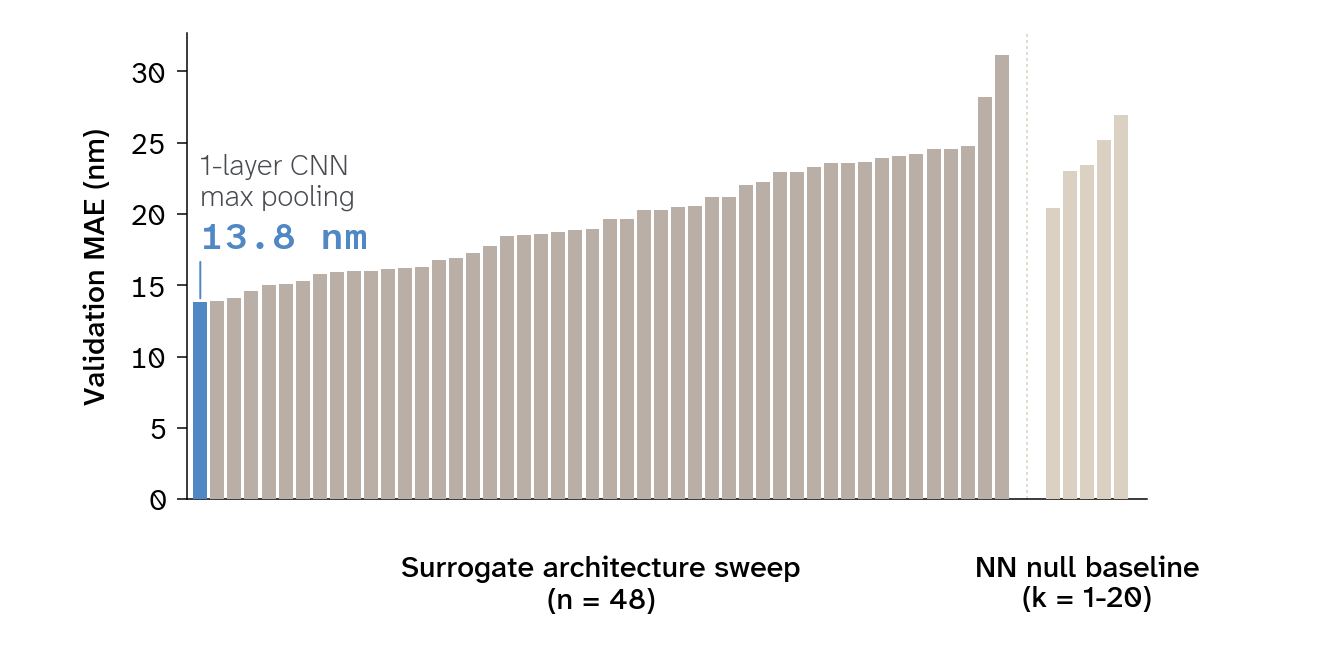

In [18]:
# Best config in HIGHLIGHT; everything else -- other configs and null baselines alike -- recedes
# into neutral tones, per the guide's "one series emphasized, the rest recede" pattern. Individual
# pooling colours are dropped: with 47 bars deliberately not the point, one shared neutral reads
# more cleanly than six. (Pooling-level detail is what sweep_results.ipynb is for.)
ranked = sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
null_items = list(nulls.items())
best = ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(ranked))
x_null = np.arange(len(null_items)) + len(ranked) + GAP
bar_color = [HIGHLIGHT if i == 0 else NEUTRAL for i in range(len(ranked))]

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.95, bottom=0.25)

ax.bar(x_cfg, ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.bar(x_null, [v for _, v in null_items], color=NEUTRAL_SOFT, width=0.82, edgecolor="none", zorder=3)
ax.axvline(len(ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Individual configs are no longer the point -- only the winner is labelled, with a leader line
# and its exact validation MAE set in the guide's mono numerals, SemiBold for emphasis.
best_text = f"{best.depth}-layer {BACKBONE_LABEL[best.arch]}\n{best['pool']} pooling"
ax.annotate(best_text, xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{best.val_mae:.1f} nm", xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": HIGHLIGHT})
ax.annotate("", xy=(0, best.val_mae), xytext=(0, best.val_mae + ranked["val_mae"].max() * 0.10),
            arrowprops=dict(arrowstyle="-", color=HIGHLIGHT, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)          # headroom so the null label clears the last bar
ax.set_ylim(0, ranked["val_mae"].max() * 1.05)
ax.set_ylabel("Validation MAE (nm)")

# No legend -- each group is labelled in place, centred under its own bars, rather than decoded
# through a key. Blended transform: x in data coordinates, y in axes fraction (below the spines).
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Surrogate architecture sweep\n(n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_val_mae.svg")
fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_val_mae.png", dpi=200)
plt.show()

**Figure 5. The winning configuration, CNN (1) - max, clears the strongest null baseline by 6.6
nm -- but 20 of the other 47 do not.** Validation MAE (nm, averaged over excitation and emission)
for all 48 backbone x pooling x depth configurations trained on the surrogate-role split of the
ESM-2 embedding (single seed), ranked ascending against an embedding-nearest-neighbour null
baseline: predict a validation protein's peak as the mean peak of its *k* nearest training proteins
in cosine distance over mean-pooled ESM-2 space (*k* = 1, 3, 5, 10, 20). The chosen surrogate is
called out directly, in Aegean; every other configuration and every null recede into neutral tones,
so the one number that matters -- 13.8 nm -- is what competes for attention, not the shape of the
other 47 bars.

Twenty of the 48 trained configurations do not beat even the strongest null (*k*=1, 20.5 nm), and
the two weakest (**TF (3) - concat** and **TF (4) - max**, 28-31 nm) fall behind every null tested.
Underneath the ranking, architecture and pooling still interact the way the full sweep shows: CNNs
degrade smoothly with depth (mean val MAE 16.0, 17.5, 19.3, 19.6 nm at depth 1-4), transformers hold
flat through depth 2 (17.5 nm at both) and then fall off a cliff at depth 3 (23.8 nm), plain mean
pooling never reaches the top 19 configurations by rank, and the learned covariance-probe pool is
competitive at CNN depth 1-2 (16.0 and 16.9 nm) but collapses to 24.1 nm at depth 3.
[`sweep_results.ipynb`](sweep_results.ipynb) breaks the full ranking down by pooling readout, for
when those patterns are the point rather than the winner.

## 6. Architecture sweep for the oracle peak model

The oracle evaluates designs independently of the surrogate: the same backbone x pooling x depth
sweep and protocol, but on a ProstT5 encoder embedding (structure-aware, 1024-d) and the
oracle-role split of `dual_splits.csv`, so it differs from the surrogate in both the pretrained
language model and the split it is scored against, not just the trained readout. Sweep code and
the full leaderboard live in the same [`sweep_peak_oracle.py`](sweep_peak_oracle.py) and
[`sweep_results.ipynb`](sweep_results.ipynb) as Figure 5; this is that sweep's ranking, in the
same style, so the two can be compared directly.

As in Figure 5, an embedding-nearest-neighbour null is pinned separately: predict a validation
protein's peak as the mean peak of its *k* nearest training proteins in mean-pooled ProstT5 space
(cosine distance, *k* = 1, 3, 5, 10, 20).

In [19]:
ORACLE_DIR = "trained_models/oracle_sweep"

# load_surrogate_sweep is generic despite the name -- any checkpoint dir with the same fields.
oracle_sweep = load_surrogate_sweep(ORACLE_DIR)
oracle_best, oracle_worst = oracle_sweep.iloc[0], oracle_sweep.iloc[-1]
print(f"{len(oracle_sweep)} configs | best {oracle_best['label']} at {oracle_best.val_mae:.1f} nm val "
      f"({oracle_best.test_mae:.1f} nm test) | worst {oracle_worst['label']} at {oracle_worst.val_mae:.1f} nm")

48 configs | best CNN (2) - max at 13.7 nm val (12.1 nm test) | worst CNN (3) - cov at 47.3 nm


In [20]:
def oracle_nn_baseline(ks=K_SWEEP):
    """Same embedding-NN null as Figure 5, on the oracle's ProstT5 cache and split."""
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/prostt5_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/prostt5_residue_len.npy").astype(int)
    role = (pd.read_csv(f"{CURATED}/dual_splits.csv")
            .sort_values("index").set_index("index")["oracle_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])
    out = {}
    for k in ks:
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
        neighbours = nn.kneighbors(X[va], return_distance=False)
        pred = peaks[tr][neighbours].mean(axis=1)
        out[f"NN k={k}"] = float(np.abs(pred - peaks[va]).mean())
    return out


oracle_nulls = oracle_nn_baseline()
n_below_best_null = int((oracle_sweep.val_mae > min(oracle_nulls.values())).sum())
n_below_worst_null = int((oracle_sweep.val_mae > max(oracle_nulls.values())).sum())
for k, v in oracle_nulls.items():
    print(f"{k:8} {v:5.1f} nm")
print(f"{n_below_best_null} of {len(oracle_sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")

NN k=1    20.8 nm
NN k=3    22.4 nm
NN k=5    24.9 nm
NN k=10   28.3 nm
NN k=20   29.9 nm
8 of 48 configs are worse than the best null; 2 are worse than every null


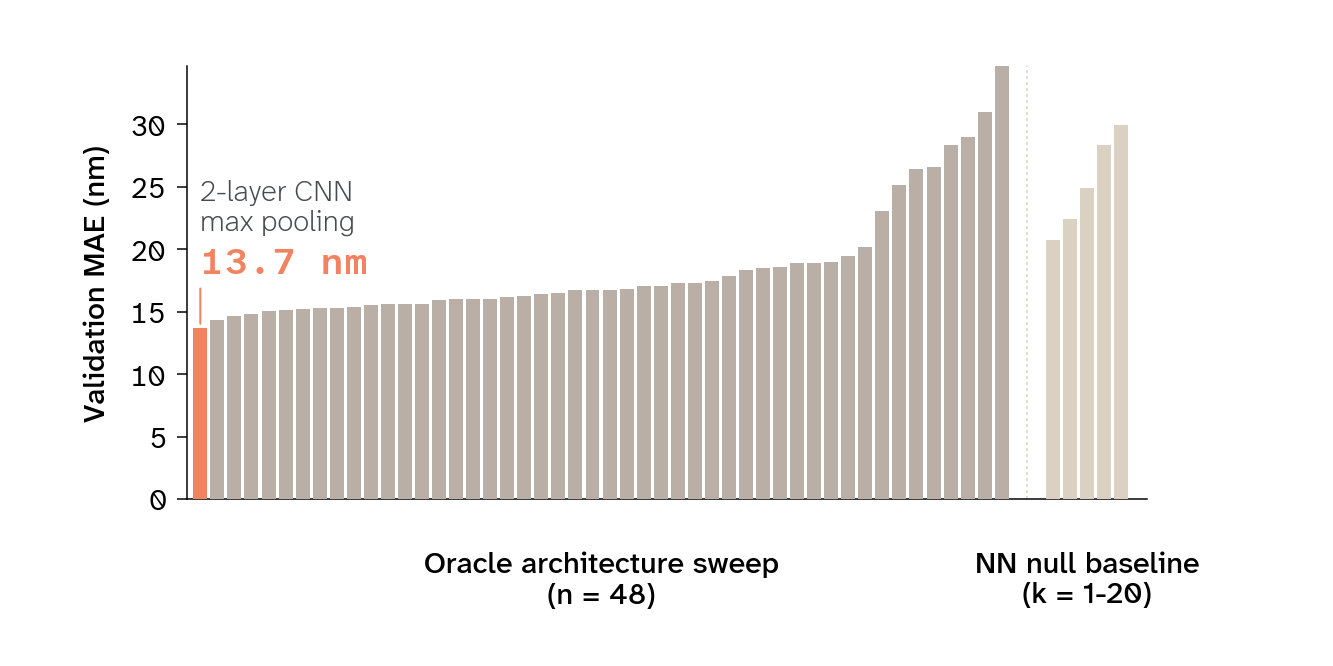

In [21]:
# Same design as Figure 5, but the winner is called out in CONTRAST (orange) rather than
# HIGHLIGHT, so the two sweep figures read as a pair with a distinct colour per model. CNN (3) -
# cov is such a severe outlier (47 nm, versus a 31 nm runner-up) that it would compress the other
# 47 bars into a sliver if the axis stretched to fit it, so the axis is capped near the runner-up
# and that one bar is simply clipped -- still present in the chart, just cut off at the top, with
# no callout text on it.
oracle_ranked = oracle_sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
oracle_null_items = list(oracle_nulls.items())
oracle_best_row = oracle_ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(oracle_ranked))
x_null = np.arange(len(oracle_null_items)) + len(oracle_ranked) + GAP
bar_color = [CONTRAST if i == 0 else NEUTRAL for i in range(len(oracle_ranked))]

ylim_max = max(oracle_ranked["val_mae"].iloc[:-1].max(),
               max(v for _, v in oracle_null_items)) * 1.12

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.9, bottom=0.25)

ax.bar(x_cfg, oracle_ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.bar(x_null, [v for _, v in oracle_null_items], color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
ax.axvline(len(oracle_ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Only the winner is labelled, with a leader line and its exact validation MAE set in the guide's
# mono numerals, SemiBold for emphasis.
best_text = f"{oracle_best_row.depth}-layer {BACKBONE_LABEL[oracle_best_row.arch]}\n{oracle_best_row['pool']} pooling"
ax.annotate(best_text, xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{oracle_best_row.val_mae:.1f} nm", xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": CONTRAST})
ax.annotate("", xy=(0, oracle_best_row.val_mae),
            xytext=(0, oracle_best_row.val_mae + ylim_max * 0.10),
            arrowprops=dict(arrowstyle="-", color=CONTRAST, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)
ax.set_ylim(0, ylim_max)
ax.set_ylabel("Validation MAE (nm)")

label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Oracle architecture sweep\n(n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.svg")
fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.png", dpi=200)
plt.show()

**Figure 6. The independent oracle picks a similar winner, CNN (2) - max, called out here in
orange to pair with the surrogate's blue in Figure 5.** Validation MAE (nm, averaged over
excitation and emission) for the same 48-configuration architecture sweep, run on the oracle's
ProstT5 embedding and oracle-role split (single seed), ranked ascending against the same
embedding-nearest-neighbour null design as Figure 4. One bar, **CNN (3) - cov**, is visibly clipped
at the axis limit rather than labelled: at 47.3 nm it is more than 1.5x the next-worst
configuration and would compress the other 47 bars into a sliver if the axis stretched to fit it,
so the axis caps near the runner-up and that one bar is simply cut off, unlabelled, rather than
clutter the panel -- its identity and value are in the leaderboard printed above and in
[`sweep_results.ipynb`](sweep_results.ipynb).

CNN (2) - max beats the strongest null (*k*=1, 20.8 nm) by 7.1 nm, slightly more room than the
surrogate's winner had. Only 8 of the 48 configurations fail to clear that same null -- fewer than
half as many as in the surrogate sweep -- and only two fall behind every null tested: **None (0) -
concatstd** (31.0 nm, the pool-only baseline, the tallest fully-visible bar) and the clipped
**CNN (3) - cov** (47.3 nm). Depth behaves differently here than in Figure 4: CNN performance is
roughly flat across depth 1-4 (16.5, 15.3, 16.1, 16.9 nm, excluding the cov outlier) rather than
degrading monotonically, while transformers still do best shallow and fall off from depth 3 onward
(17.6, 16.7, 19.0, 20.2 nm) -- the one architectural trend that agrees with the surrogate sweep.
Mean pooling fares much better on the oracle than it did on the surrogate: **CNN (3) - mean**
reaches rank 14 (15.7 nm), where mean pooling never broke the top 19 in Figure 4. The
covariance-probe pool is otherwise strong here, competitive with the leaders at CNN depth 1-2
(15.3 and 15.1 nm), which makes its depth-3 failure read less like a gentle overfit and more like a
specific numerical breakdown at that width/depth combination.

## 7. Test-set predictions: best surrogate model

Figures 5 and 6 ranked all 48 configs by validation MAE -- the number the sweep actually selects
on. Here the surrogate sweep's winner (CNN (1) - max) is run once more, forward-only, on its own
held-out **test** split (never touched by early stopping), so the reported numbers are a genuinely
unseen check rather than the val_mae used to pick the winner. The oracle's equivalent is Figure 8.

In [22]:
import peak_models as pm
import sweep_peak_oracle as spo

dev = spo.device()


def predict_split(ckpt_path, D, idx):
    """Run a saved (arch, pool, depth) checkpoint over D's idx rows -> (n, 2) nm predictions."""
    base, ck = pm.load_model(ckpt_path, dev, out=2)
    net = pm.wrap(base, ck["mean"], ck["std"], dev)
    net.eval()
    ps = []
    with torch.no_grad():
        for Hb, mk, b in spo.batches(D, idx, dev):
            ps.append(net(Hb, mk).cpu().numpy())
    return np.concatenate(ps)


def col_metrics(p, t):
    """MAE (nm) / Pearson r / R2 / n for one true-vs-predicted column."""
    r2 = 1.0 - float(np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2))
    return dict(mae=float(np.abs(p - t).mean()), r=float(np.corrcoef(p, t)[0, 1]), r2=r2, n=len(t))


def test_metrics(role, out_dir, row):
    """Predictions on role's test split, plus MAE/r/R2/n pooled (ex_max and em_max together,
    matching how the sweep itself averages test_mae) and separately per peak.
    """
    D = spo.load_data(role, dev)
    ckpt = os.path.join(out_dir, f"{row.arch}-{row.pool}-d{row.depth}_s0.pt")
    P = predict_split(ckpt, D, D["te"])
    T = D["Pk"].cpu().numpy()[D["te"]]
    return dict(P=P, T=T, row=row, pooled=col_metrics(P.ravel(), T.ravel()),
                ex=col_metrics(P[:, 0], T[:, 0]), em=col_metrics(P[:, 1], T[:, 1]))


surr_test = test_metrics("surrogate", SURR_DIR, best)
oracle_test = test_metrics("oracle", ORACLE_DIR, oracle_best)

for name, m in [("surrogate", surr_test), ("oracle", oracle_test)]:
    print(f"{name} ({m['row']['label']}):")
    for k, lab in [("pooled", "pooled (ex+em)"), ("ex", "excitation "), ("em", "emission  ")]:
        v = m[k]
        print(f"  {lab}  MAE={v['mae']:5.2f} nm  r={v['r']:.3f}  R2={v['r2']:.3f}  n={v['n']}")

surrogate (CNN (1) - max):
  pooled (ex+em)  MAE=14.40 nm  r=0.889  R2=0.787  n=236
  excitation   MAE=17.86 nm  r=0.835  R2=0.687  n=118
  emission    MAE=10.95 nm  r=0.925  R2=0.855  n=118
oracle (CNN (2) - max):
  pooled (ex+em)  MAE=12.11 nm  r=0.939  R2=0.878  n=224
  excitation   MAE=13.61 nm  r=0.926  R2=0.853  n=112
  emission    MAE=10.62 nm  r=0.943  R2=0.880  n=112


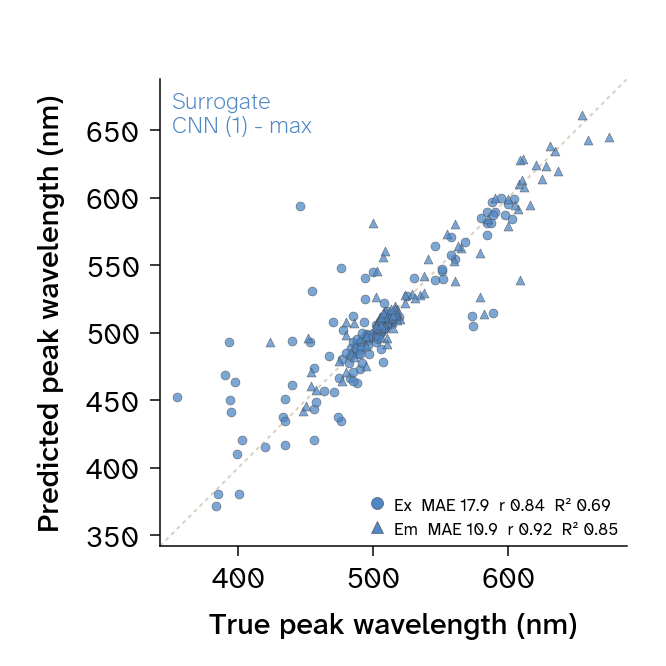

In [23]:
from matplotlib.lines import Line2D

EX_MARKER, EM_MARKER = "o", "^"


def plot_pred_scatter(name, m, color, fname):
    """True-vs-predicted peak wavelength for one model's test split. Excitation/emission are
    distinct marker shapes in the model's own colour; the legend carries MAE/r/R2 per peak,
    since the sweep's own selection metric (val MAE) averages over both and can hide a gap
    between them.
    """
    fig, ax = plt.subplots(figsize=(FULL_WIDE / 3 * PX, FULL_WIDE / 3 * PX))
    fig.subplots_adjust(left=0.24, right=0.94, bottom=0.18, top=0.88)

    lo, hi = min(m["P"].min(), m["T"].min()), max(m["P"].max(), m["T"].max())
    pad = 0.04 * (hi - lo)
    lim = (lo - pad, hi + pad)
    ax.plot(lim, lim, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=1, zorder=1)
    ax.scatter(m["T"][:, 0], m["P"][:, 0], s=20, marker=EX_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=0.75, zorder=2)
    ax.scatter(m["T"][:, 1], m["P"][:, 1], s=20, marker=EM_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=0.75, zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_box_aspect(1)
    ax.set_xlabel("True peak wavelength (nm)"); ax.set_ylabel("Predicted peak wavelength (nm)")

    # Identity + config labelled in place (top-left, model colour) rather than an axes title --
    # in-figure titles are the caption's job per the guide.
    ax.annotate(f"{name}\n{m['row']['label']}", xy=(0, 1), xycoords="axes fraction",
                xytext=(6, -6), textcoords="offset points", ha="left", va="top",
                **{**ANNOTATION, "fontsize": 12, "color": color})

    handles = [
        Line2D([], [], marker=EX_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Ex  MAE {m['ex']['mae']:.1f}  r {m['ex']['r']:.2f}  R² {m['ex']['r2']:.2f}"),
        Line2D([], [], marker=EM_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Em  MAE {m['em']['mae']:.1f}  r {m['em']['r']:.2f}  R² {m['em']['r2']:.2f}"),
    ]
    # style_plot auto-detects any legend on the axes and calls the buggy style_legend() (stray
    # rule-under-title line, see notebook conventions) -- style the plot BEFORE adding the legend,
    # then style the legend by hand with the same two safe helpers style_legend uses.
    apc.mpl.style_plot(ax, monospaced_axes="both")
    leg = ax.legend(handles=handles, loc="lower right", fontsize=8.5, frameon=True,
                    handletextpad=0.5, borderpad=0.5, labelspacing=0.4)
    leg.get_frame().set_edgecolor("none"); leg.get_frame().set_alpha(0.85)
    apc.mpl.capitalize_legend_text(leg)
    apc.mpl.justify_legend_text(leg)

    fig.savefig(f"{FIGDIR}/{fname}.svg")
    fig.savefig(f"{FIGDIR}/{fname}.png", dpi=200)
    plt.show()


plot_pred_scatter("Surrogate", surr_test, HIGHLIGHT, "peak_surrogate_test_predictions")

**Figure 7. The surrogate's held-out test predictions track the true peak well overall, but are
noticeably worse on excitation than emission.** Predicted vs. true peak wavelength for CNN (1) -
max (ESM-2), the surrogate sweep's validation-selected winner, run once on its **test** split
(never touched during training or early stopping): excitation MAE 17.9 nm / r 0.84 / R² 0.69 vs.
emission MAE 10.9 nm / r 0.92 / R² 0.85 (n = 118 test proteins each). The fit tracks the diagonal
well through the crowded ~480-530 nm core where most curated FPs sit; the sparser tails past 600 nm
and below 420 nm carry most of the visible scatter, and disproportionately more of it lands on
excitation. Figure 8 is the oracle's equivalent, on its own independent test split.

## 8. Test-set predictions: best oracle model

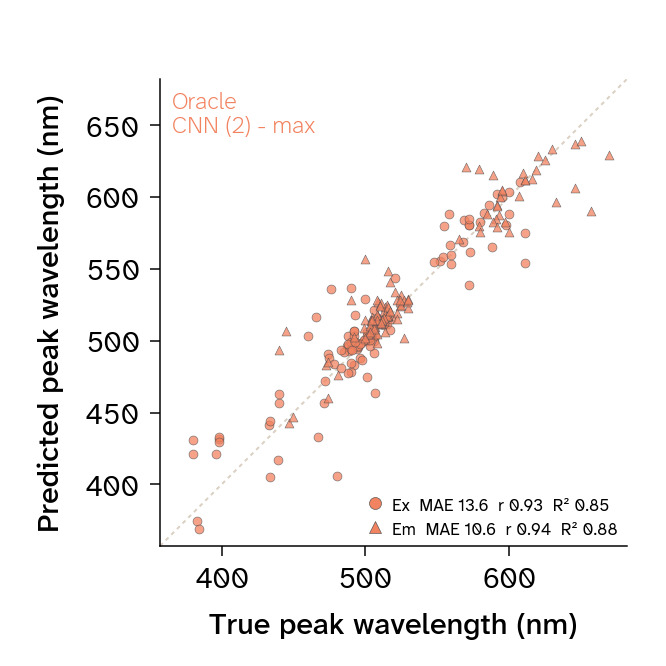

In [24]:
plot_pred_scatter("Oracle", oracle_test, CONTRAST, "peak_oracle_test_predictions")

**Figure 8. The independent oracle is better calibrated than the surrogate overall, and the
excitation/emission gap that hurts the surrogate is far smaller here.** Predicted vs. true peak
wavelength for CNN (2) - max (ProstT5), the oracle sweep's validation-selected winner, run once on
its own **test** split: excitation MAE 13.6 nm / r 0.93 / R² 0.85 vs. emission MAE 10.6 nm / r 0.94
/ R² 0.88 (n = 112 test proteins each) -- still emission-favoured, but a much smaller gap than
Figure 7's. This is consistent with the oracle's own architecture sweep (Figure 6) beating its
strongest null by a wider margin than the surrogate's sweep did (7.1 nm vs. the surrogate's smaller
gap in Figure 5) -- a different pLM and split, but not a weaker model.